# Variational Autoencoder (VAE) - PyTorch


## Architecture Notes

- **What it learns:** A probabilistic latent space supports reconstruction and sampling.
- **Where it is used:** generative modeling, latent-space exploration, and controllable sampling.
- **Why it works:** the architecture builds a useful bias into the computation, so the model does not need to rediscover that structure from data alone.
- **Output to expect:** classification models return class scores/probabilities, reconstruction models return reconstructed inputs, and generative models return new or denoised samples.


A **Variational Autoencoder (VAE)** is an improved version of a standard Autoencoder.

Unlike a normal AE:

* AE learns a compressed vector directly.
* VAE learns a **probability distribution** in latent space.

This makes VAEs capable of:

* generating new images,
* learning smooth latent representations,
* interpolation between samples.

# Key Idea of VAE

Instead of learning:

```text
x → z → reconstructed x
```

VAE learns:

```text
x → (μ, σ) → sampled z → reconstructed x
```

Where:

* `μ` = mean
* `σ` = standard deviation
* `z` is sampled from a Gaussian distribution

---

# Important Concepts

## 1. Mean and Variance

The encoder outputs:

```text
μ (mean)
logσ² (log variance)
```

instead of a fixed vector.

---

## 2. Reparameterization Trick

Core VAE innovation:

```python
z = mu + eps * std
```

Where:

* `eps ~ N(0,1)`
* allows backpropagation through randomness.

---

## 3. KL Divergence Loss

VAE loss has two parts:

### Reconstruction Loss

Measures image reconstruction quality.

### KL Divergence

Forces latent space toward a standard Gaussian distribution.

---

# VAE Loss Formula

The VAE objective is:

$$\mathcal{L} = \text{Reconstruction Loss} + D_{KL}(q(z|x)\parallel p(z))$$

KL divergence term:

$$D_{KL} = -\frac{1}{2}\sum(1 + \log(\sigma^2) - \mu^2 - \sigma^2)$$

---

# Why VAE is Better than Standard AE

| AE                               | VAE                            |
| -------------------------------- | ------------------------------ |
| Learns fixed latent vector       | Learns latent distribution     |
| Good reconstruction              | Good generation                |
| Cannot generate new samples well | Can generate realistic samples |
| Discontinuous latent space       | Smooth latent space            |

---

# Applications of VAE

VAEs are used in:

* image generation,
* anomaly detection,
* representation learning,
* drug discovery,
* recommender systems,
* face generation,
* latent space interpolation.


Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]


VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Epoch [1/20] Loss: 164.3884
Epoch [2/20] Loss: 121.5075
Epoch [3/20] Loss: 114.6514
Epoch [4/20] Loss: 111.7260
Epoch [5/20] Loss: 109.9547
Epoch [6/20] Loss: 108.7707
Epoch [7/20] Loss: 107.8581
Epoch [8/20] Loss: 107.2243
Epoch [9/20] Loss: 106.7353
Epoch [10/20] Loss: 106.3121
Epoch [11/20] Loss: 105.9031
Epoch [12/20] Loss: 105.5926
Epoch [13/20] Loss: 105.2767
Epoch [14/20] Loss: 105.0422
Epoch [15/20] Loss: 104.8020
Epoch [16/20] Loss: 104.5983
Epoch [17/20] Loss: 104.4524
Epoch [18/20] Loss: 104.2310
Epoch [19/20] Loss: 104.0814
Epoch [20/20] Loss: 103.9129
Training Finished!


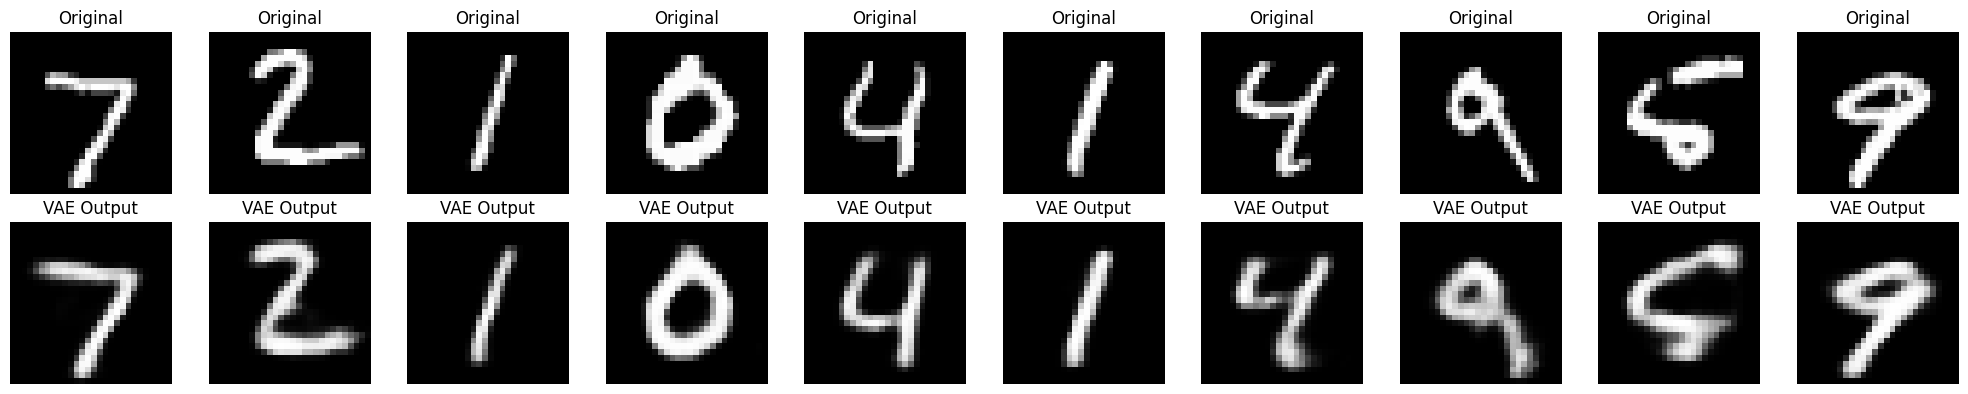

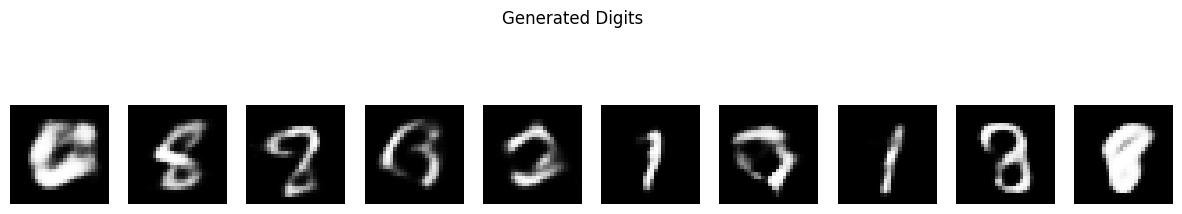

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# 1. Device Configuration
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2. Load MNIST Dataset
# =========================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True)

test_loader = DataLoader(
    test_dataset,
    batch_size=10,
    shuffle=False)

# =========================
# 3. Define VAE Model
# =========================
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Mean and Variance layers
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    # Encoder
    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization Trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Decoder
    def decode(self, z):
        h = self.relu(self.fc2(z))
        return self.sigmoid(self.fc3(h))

    # Forward Pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

# Initialize model
model = VAE().to(device)
print(model)

# =========================
# 4. Loss Function
# =========================
def vae_loss(reconstructed, original, mu, logvar):
    # Reconstruction Loss
    recon_loss = nn.functional.binary_cross_entropy(
        reconstructed,
        original,
        reduction='sum'
    )

    # KL Divergence
    kl_div = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_div

# =========================
# 5. Optimizer
# =========================
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =========================
# 6. Train VAE
# =========================
epochs = 20
model.train()

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        # Flatten images
        images = images.view(images.size(0), -1)

        # Forward pass
        reconstructed, mu, logvar = model(images)

        # Compute loss
        loss = vae_loss(reconstructed, images, mu, logvar)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

print("Training Finished!")

# =========================
# 7. Reconstruction Results
# =========================
model.eval()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        images_flat = images.view(images.size(0), -1)

        reconstructed, _, _ = model(images_flat)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        images = images.cpu()
        reconstructed = reconstructed.cpu()
        break

# =========================
# 8. Visualize Reconstruction
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("VAE Output")
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 9. Generate New Digits
# =========================
with torch.no_grad():
    # Random latent vectors
    z = torch.randn(10, 20).to(device)
    generated = model.decode(z)
    generated = generated.view(-1, 28, 28).cpu()

# Plot generated images
plt.figure(figsize=(15, 3))

for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated[i], cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Digits")
plt.show()